In [13]:
import pandas as pd
from scipy.fft import rfft, rfftfreq
import numpy as np

In [14]:
# load the data from the CSV file
data_file = 'data/accel_data_500Hz.csv'
data = pd.read_csv(data_file)
data

,pc_time,packet_counter,arduino_time_us,ax_raw,ay_raw,az_raw
0,1.777788e+09,0,2008,-0.241635,-0.452799,0.890717
1,1.777788e+09,0,4016,-0.302579,-0.574686,0.950035
2,1.777788e+09,0,6024,-0.302579,-0.574686,0.890717
3,1.777788e+09,1,8028,-0.363522,-0.696573,0.950035
4,1.777788e+09,1,10036,-0.424466,-0.757517,1.009353
...,...,...,...,...,...,...
3298,1.777788e+09,1099,6615052,0.032610,0.065220,0.977207
3299,1.777788e+09,1099,6617060,0.032610,0.065220,0.977207
3300,1.777788e+09,1100,6619068,0.063082,0.034748,1.009353
3301,1.777788e+09,1100,6621072,0.063082,0.095692,1.009353


In [15]:
# get avg frequency of samples
time_between_samples = data['arduino_time_us'].diff().dropna()
avg_freq = 1 / (10 ** -6 * time_between_samples.mean())
avg_freq

np.float64(498.71078278562754)

In [16]:
list(data['arduino_time_us'].diff())[0:50]

[nan,
 2008.0,
 2008.0,
 2004.0,
 2008.0,
 2004.0,
 2004.0,
 2004.0,
 2008.0,
 2004.0,
 2004.0,
 2004.0,
 2004.0,
 2008.0,
 2004.0,
 2004.0,
 2008.0,
 2004.0,
 2004.0,
 2004.0,
 2004.0,
 2004.0,
 2008.0,
 2008.0,
 2008.0,
 2004.0,
 2004.0,
 2004.0,
 2004.0,
 2008.0,
 2008.0,
 2004.0,
 2004.0,
 2008.0,
 2004.0,
 2004.0,
 2008.0,
 2004.0,
 2008.0,
 2004.0,
 2008.0,
 2004.0,
 2004.0,
 2008.0,
 2004.0,
 2008.0,
 2008.0,
 2008.0,
 2008.0,
 2008.0]

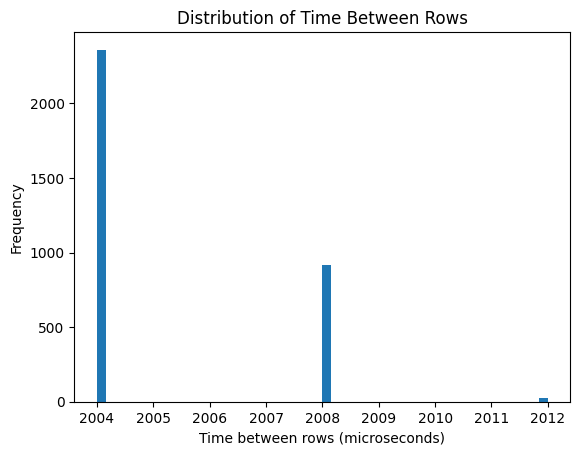

In [17]:
# plot the distribution of t_us between rows
import matplotlib.pyplot as plt
plt.hist(data['arduino_time_us'].diff().dropna(), bins=50)
plt.xlabel('Time between rows (microseconds)')
plt.ylabel('Frequency')
plt.title('Distribution of Time Between Rows')
plt.show()

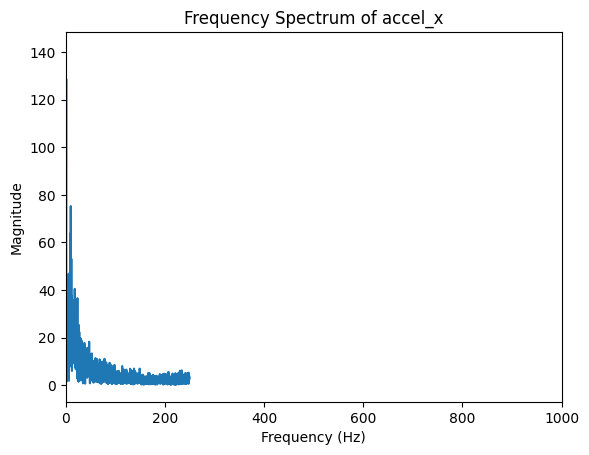

In [18]:
# perform frequency analysis on accel data
# Number of samples
N = len(data)
# Sample spacing
T = 1 / avg_freq
# Perform FFT on accel_x
yf = rfft(data['ax_raw'])
xf = rfftfreq(N, T)
plt.plot(xf, np.abs(yf))
plt.xlabel('Frequency (Hz)')
plt.ylabel('Magnitude')
plt.title('Frequency Spectrum of accel_x')
plt.xlim(0, 1000)  # Limit x-axis to 1000 Hz
plt.show()